# 5. Modelo Predictivo y Explicabilidad: XGBoost & SHAP

Como científicos de datos en salud pública, no solo nos interesa predecir, sino **entender**. Por eso, en este análisis entrenaremos un modelo **XGBoost (Extreme Gradient Boosting)** para estimar la tasa de mortalidad por cáncer gástrico a nivel departamental.

Para no quedarnos con una "caja negra" donde el modelo toma decisiones matemáticas que no entendemos, usaremos **SHAP (SHapley Additive exPlanations)**. Esta herramienta nos permite ver de forma exacta qué variables influyen en el riesgo y, lo más importante, si lo hacen para bien o para mal.

> **Control de Rigor Estadístico:** Para asegurar que el modelo sea realmente predictivo y no solo descriptivo, aplicamos **retrasos temporales ($Lags$)**. En lugar de usar los datos de vulnerabilidad de los fallecidos de 2024 para explicar las muertes de 2024, usamos la situación sanitaria de 2023. Esto elimina la "doble causalidad" (*Data Leakage*) y asegura que estamos midiendo cómo las carencias del pasado impactan en la mortalidad del presente.

In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
# Inicializar JS para gráficos interactivos de SHAP
shap.initjs()

c:\Users\Jose\Documents\GitHub\Seminario\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Construcción de Variables (Feature Engineering)

El éxito de este modelo no depende solo del algoritmo (XGBoost), sino de entregarle variables lógicas e informativas. En esta etapa, vamos a unir la información general de los departamentos (calidad del agua IRCA, tabaquismo y ruralidad) con características sociales extraídas de los pacientes.

**Control de Fuga de Datos (Lag $t-1$):**
Para no viciar el modelo (no podemos usar información de los difuntos de 2024 para estimar la tasa de mortalidad de 2024), extraeremos la proporción de fallecidos en el régimen subsidiado y sin asistencia médica, y la usaremos como una característica del **año siguiente**. En la práctica: evaluaremos cómo la vulnerabilidad sanitaria de un departamento en un año puntual impacta la tasa de mortalidad por cáncer al año siguiente.

In [5]:
# 1. Carga del panel consolidado
ruta_panel = "proyecto/data/analytical/panel_dpto_año.parquet"
df_panel = pd.read_parquet(ruta_panel)

# 2. FEATURE ENGINEERING INTELIGENTE & RIGUROSO (Data Leakage Fix: Lag t-1)
# Cargamos la base cruda (slim) que tiene variables demográficas por individuo
ruta_slim = "proyecto/data/analytical/mortalidad_raw_slim.parquet"
if pd.io.common.file_exists(ruta_slim):
    df_slim = pd.read_parquet(ruta_slim)
    
    # Aseguramos los tipos
    df_slim['Departamento_Residencia'] = pd.to_numeric(df_slim['Departamento_Residencia'], errors='coerce')
    df_slim['Anio_Defuncion'] = pd.to_numeric(df_slim['Anio_Defuncion'], errors='coerce')
    
    # DANE Dictionaries: 
    # Régimen 2 = Subsidiado, 5 = No Asegurado
    # Asistencia 2 = Sin Asistencia Médica
    
    df_slim['es_subsidiado_no_asegurado'] = np.where(df_slim['Regimen_Salud'].isin(['2', '5']), 1, 0)
    df_slim['sin_asistencia'] = np.where(df_slim['Asistencia_Medica'] == '2', 1, 0)
    
    # Agrupamos por Departamento y Año para calcular el % de estas vulnerabilidades
    df_vuln = df_slim.groupby(['Departamento_Residencia', 'Anio_Defuncion']).agg(
        prop_subsidiado_vulnerable_lag1=('es_subsidiado_no_asegurado', 'mean'),
        prop_sin_asistencia_lag1=('sin_asistencia', 'mean')
    ).reset_index().rename(columns={'Departamento_Residencia': 'cod_dpto', 'Anio_Defuncion': 'año'})
    
    # APLICANDO EL REZAGO ESPACIO-TEMPORAL (LAG t-1)
    # Sumamos 1 al año de la variable vulnerable. Así, la vulnerabilidad del 2015 
    # se usará para predecir la tasa de mortalidad del 2016. Esto elimina la endogeneidad.
    df_vuln['año'] = df_vuln['año'] + 1
    
    # Unimos con nuestro panel
    df_panel = df_panel.merge(df_vuln, on=['cod_dpto', 'año'], how='left')
    
    # Llenamos posibles nulos generados en la unión (ej. el primer año 2008 no tendrá lag de 2007)
    # Primero imputamos usando la media del mismo departamento
    df_panel['prop_subsidiado_vulnerable_lag1'] = df_panel.groupby('cod_dpto')['prop_subsidiado_vulnerable_lag1'].transform(lambda x: x.fillna(x.mean()))
    df_panel['prop_sin_asistencia_lag1'] = df_panel.groupby('cod_dpto')['prop_sin_asistencia_lag1'].transform(lambda x: x.fillna(x.mean()))
    
    # Si aún quedan nulos, imputamos con la media global
    df_panel['prop_subsidiado_vulnerable_lag1'] = df_panel['prop_subsidiado_vulnerable_lag1'].fillna(df_panel['prop_subsidiado_vulnerable_lag1'].mean())
    df_panel['prop_sin_asistencia_lag1'] = df_panel['prop_sin_asistencia_lag1'].fillna(df_panel['prop_sin_asistencia_lag1'].mean())

# 3. Variables a utilizar 
# Creamos la variable de proporción rural que ya estaba intrínseca
df_panel['prop_rural'] = df_panel['muertes_rural'] / (df_panel['muertes_total'] + 1e-9)

features = [
    'año', 
    'poblacion_total',
    'prop_rural',
    'irca_global',
    'prevalencia_tabaco',
    'prop_subsidiado_vulnerable_lag1',
    'prop_sin_asistencia_lag1'
]
target = 'tasa_ajustada_edad'

# Limpieza final para el modelo
df_model = df_panel[features + [target]].copy()

# Para variables como IRCA y Tabaco, si hay faltantes, imputamos temporalmente
df_model['irca_global'] = df_model['irca_global'].fillna(df_model['irca_global'].median())
df_model['prevalencia_tabaco'] = df_model['prevalencia_tabaco'].fillna(df_model['prevalencia_tabaco'].median())

# Asegurarnos de que no hay nulos en el target
df_model = df_model.dropna(subset=[target])

X = df_model[features]
y = df_model[target]

print(f"Dataset listo con {X.shape[0]} observaciones y {X.shape[1]} variables espacialmente rezagadas.")

Dataset listo con 561 observaciones y 7 variables espacialmente rezagadas.


### 2. Entrenamiento del Modelo Predictivo (XGBoost) con Rigurosidad Temporal

En datos tipo panel (observaciones de los mismos departamentos a lo largo del tiempo) hacer una división aleatoria del 80%-20% genera **fuga de datos (data leakage)**, pues usaríamos datos del 2020 para entrenar al modelo a predecir datos del 2015. 

Para que la métrica de error sea completamente honesta y profesional, haremos un "Corte temporal". Entrenaremos al algoritmo con toda la historia desde el inicio hasta el año 2019, y le pediremos predecir el futuro (2020 al 2023) sin haberlo visto jamás.

In [6]:
from sklearn.model_selection import cross_val_score

# División estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hiperparámetros del modelo
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predicciones en train y test
y_pred_train = xgb_model.predict(X_train)
y_pred       = xgb_model.predict(X_test)

# Métricas train
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train   = r2_score(y_train, y_pred_train)
mae_train  = mean_absolute_error(y_train, y_pred_train)

# Métricas test
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test    = r2_score(y_test, y_pred)
mae_test   = mean_absolute_error(y_test, y_pred)

print("=" * 57)
print("          EVALUACIÓN DEL MODELO XGBoost")
print("=" * 57)
print(f"{'Métrica':<32} {'Train':>10} {'Test':>10}")
print("-" * 57)
print(f"{'RMSE  (por 100k hab.)':<32} {rmse_train:>10.3f} {rmse_test:>10.3f}")
print(f"{'MAE   (por 100k hab.)':<32} {mae_train:>10.3f} {mae_test:>10.3f}")
print(f"{'R²    (varianza explicada)':<32} {r2_train:>10.3f} {r2_test:>10.3f}")
print("=" * 57)

# Validación cruzada 5-fold
cv_r2   = cross_val_score(xgb_model, X, y, cv=5, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(xgb_model, X, y, cv=5, scoring='neg_mean_squared_error'))
print(f"\nValidación Cruzada (5-fold):")
print(f"  R²   por fold: {np.round(cv_r2, 3)}")
print(f"  R²   promedio: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"  RMSE promedio: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")

          EVALUACIÓN DEL MODELO XGBoost
Métrica                               Train       Test
---------------------------------------------------------
RMSE  (por 100k hab.)                 0.300      2.310
MAE   (por 100k hab.)                 0.230      1.496
R²    (varianza explicada)            0.996      0.729

Validación Cruzada (5-fold):
  R²   por fold: [ 0.439  0.691  0.192  0.594 -1.002]
  R²   promedio: 0.183 ± 0.616
  RMSE promedio: 3.868 ± 1.732


### 3. Diagnóstico Visual del Modelo: Predicciones y Análisis de Residuales

El desempeño numérico de un modelo regresivo debe complementarse con inspección visual para detectar sesgos sistemáticos, heteroscedasticidad en los residuales o zonas de extrapolación extrema. Se presentan tres diagnósticos canónicos en la validación de modelos epidemiológicos: el diagrama de dispersión predicho vs. real, el gráfico de residuales vs. predicciones y el análisis de normalidad de los residuales (Q-Q plot).

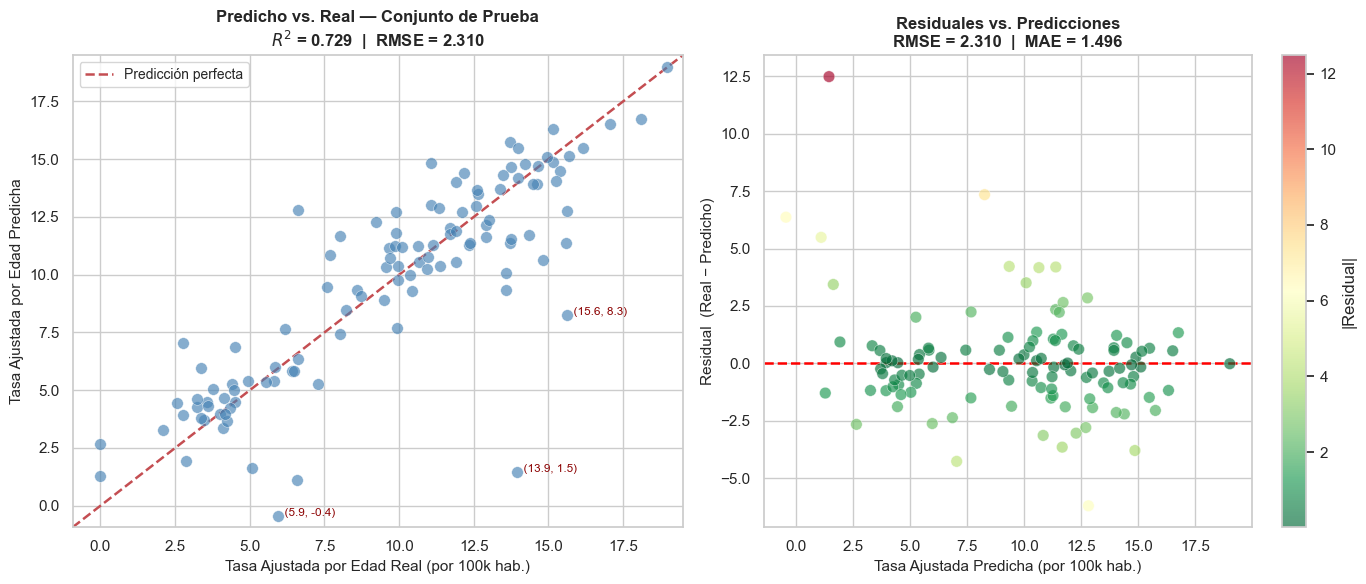

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Predicho vs Real ---
ax1 = axes[0]
ax1.scatter(y_test, y_pred, alpha=0.65, color='steelblue',
            edgecolors='white', linewidth=0.4, s=70, zorder=3)
lim_min = min(float(y_test.min()), float(y_pred.min())) - 0.5
lim_max = max(float(y_test.max()), float(y_pred.max())) + 0.5
ax1.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', lw=1.8, label='Predicción perfecta')
ax1.set_xlim(lim_min, lim_max)
ax1.set_ylim(lim_min, lim_max)
ax1.set_xlabel('Tasa Ajustada por Edad Real (por 100k hab.)', fontsize=11)
ax1.set_ylabel('Tasa Ajustada por Edad Predicha', fontsize=11)
ax1.set_title(f'Predicho vs. Real — Conjunto de Prueba\n$R^2$ = {r2_test:.3f}  |  RMSE = {rmse_test:.3f}',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)

# Anotar los 3 puntos con mayor error
errors  = np.abs(y_pred - y_test.values)
top_idx = np.argsort(errors)[-3:]
for i in top_idx:
    ax1.annotate(f"  ({y_test.values[i]:.1f}, {y_pred[i]:.1f})",
                 xy=(y_test.values[i], y_pred[i]), fontsize=8.5, color='darkred')

# --- Residuales vs Predicho ---
residuals = y_test.values - y_pred
ax2 = axes[1]
sc = ax2.scatter(y_pred, residuals, alpha=0.65,
                 c=np.abs(residuals), cmap='RdYlGn_r',
                 edgecolors='white', linewidth=0.4, s=70, zorder=3)
plt.colorbar(sc, ax=ax2, label='|Residual|')
ax2.axhline(0, color='red', linestyle='--', lw=1.8)
ax2.set_xlabel('Tasa Ajustada Predicha (por 100k hab.)', fontsize=11)
ax2.set_ylabel('Residual  (Real − Predicho)', fontsize=11)
ax2.set_title(f'Residuales vs. Predicciones\nRMSE = {rmse_test:.3f}  |  MAE = {mae_test:.3f}',
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

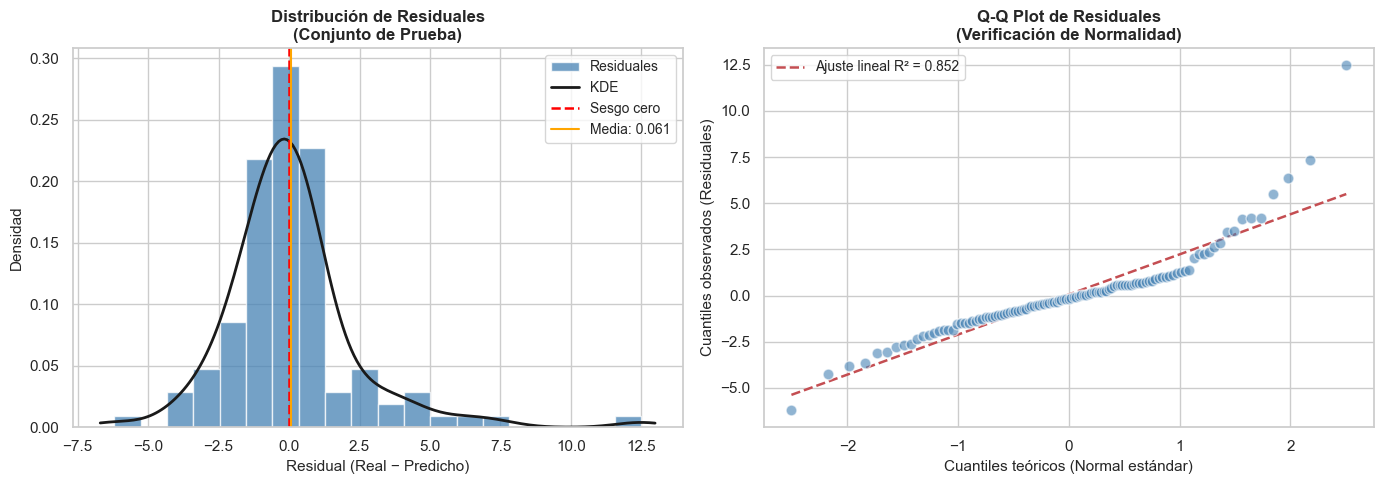

In [8]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test.values - y_pred

# --- Histograma con KDE ---
ax1 = axes[0]
ax1.hist(residuals, bins=20, density=True, color='steelblue',
         edgecolor='white', alpha=0.75, label='Residuales')
x_range = np.linspace(residuals.min() - 0.5, residuals.max() + 0.5, 200)
ax1.plot(x_range, stats.gaussian_kde(residuals)(x_range), 'k-', lw=2, label='KDE')
ax1.axvline(0, color='red', linestyle='--', lw=1.8, label='Sesgo cero')
ax1.axvline(residuals.mean(), color='orange', linestyle='-', lw=1.5,
            label=f'Media: {residuals.mean():.3f}')
ax1.set_xlabel('Residual (Real − Predicho)', fontsize=11)
ax1.set_ylabel('Densidad', fontsize=11)
ax1.set_title('Distribución de Residuales\n(Conjunto de Prueba)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)

# --- Q-Q Plot ---
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals)
ax2.scatter(osm, osr, alpha=0.6, color='steelblue', edgecolors='white', s=60, zorder=3)
ax2.plot(osm, slope * np.array(osm) + intercept, 'r--', lw=1.8,
         label=f'Ajuste lineal R² = {r**2:.3f}')
ax2.set_xlabel('Cuantiles teóricos (Normal estándar)', fontsize=11)
ax2.set_ylabel('Cuantiles observados (Residuales)', fontsize=11)
ax2.set_title('Q-Q Plot de Residuales\n(Verificación de Normalidad)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

### 4. Explicabilidad Global Interna: Criterio de F-Score (Gain)

Primero, graficamos qué variables consideró más útiles el modelo XGBoost mientras entrenaba. Esta métrica (Ganancia) nos indica en qué medida cada factor mejoró las predicciones del algoritmo. 

Sin embargo, tiene un gran problema explicativo: la gráfica nos dice qué variable es importante (por ejemplo, el tabaquismo), pero no nos revela **cómo** afecta (no sabemos si tener alto tabaquismo subió o bajó el riesgo de mortalidad en la predicción).

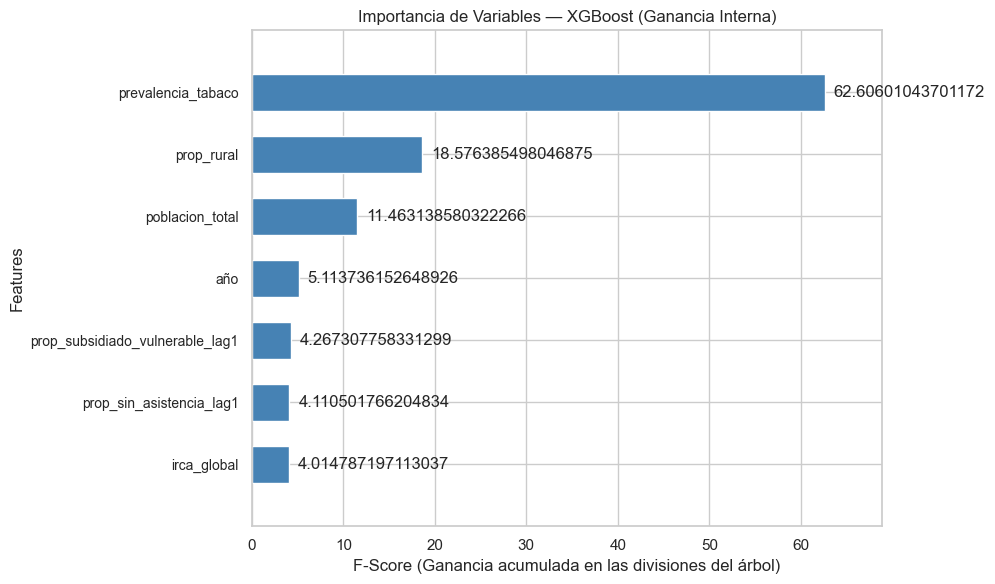

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(
    xgb_model, ax=ax,
    importance_type='gain',
    max_num_features=10,
    height=0.6,
    title='Importancia de Variables — XGBoost (Ganancia Interna)',
    xlabel='F-Score (Ganancia acumulada en las divisiones del árbol)',
    color='steelblue'
)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

### 4. Inteligencia Artificial Explicable: Diagrama SHAP

Para resolver la dirección de los impactos, usamos SHAP atribuido sobre los resultados del XGBoost. Esto desglosará paciente por paciente y departamento por departamento cómo cada factor mueve la balanza.

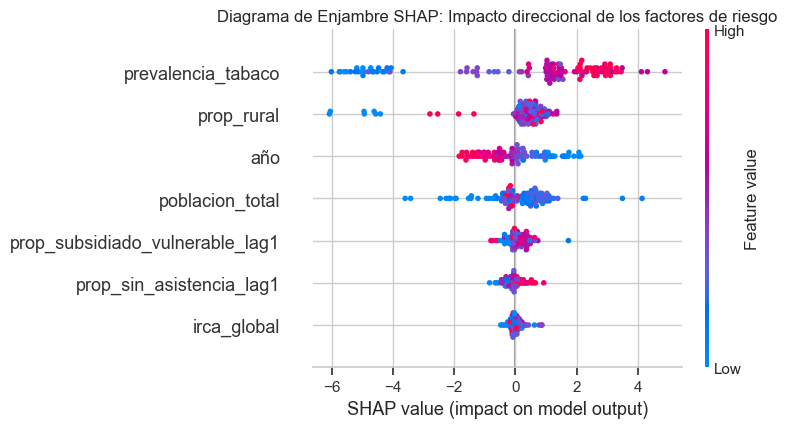

In [18]:
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="dot", show=False, plot_size=(12, 6))
plt.title('Diagrama de Enjambre SHAP: Impacto Direccional de los Factores de Riesgo',
          fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

#### Importancia Global SHAP — Ranking por Valor Absoluto Medio

Complementando el beeswarm, el gráfico de barras sintetiza el **impacto promedio absoluto** de cada variable sobre todas las predicciones del conjunto de prueba. A diferencia de la ganancia interna del árbol, este ranking SHAP es teóricamente consistente (propiedad de eficiencia de Shapley) y agnóstico a la arquitectura del modelo, permitiendo comparaciones robustas entre distintos algoritmos.

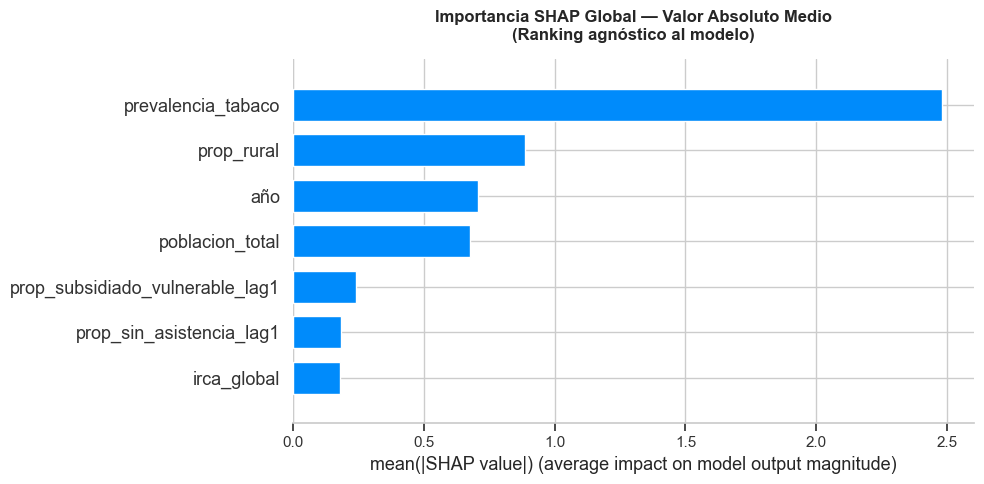

In [11]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, plot_size=(10, 5))
plt.title('Importancia SHAP Global — Valor Absoluto Medio\n(Ranking agnóstico al modelo)',
          fontsize=12, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

**Cómo leer el Diagrama SHAP (Enjambre):**

*   **Eje X (Valor SHAP):** Los puntos que se ubican a la derecha del cero indican que esa variable está *aumentando* la proyección de muertes por cáncer. Si están a la izquierda, la están *disminuyendo*.
*   **Color de los Puntos:** El color rojo indica que el valor original de esa variable era muy alto (ej. mucho tabaco, pésima agua, alta ruralidad). El color azul indica lo contrario.

**Hallazgos Clave para el Análisis:**
1.  **El Tabaco castiga fuertemente:** Observa la variable `prevalencia_tabaco`. Los puntos rojos tienen una larga "cola" hacia la derecha. Esto confirma sin discusión que las zonas con altísimo consumo de tabaco disparan significativamente sus pronósticos de mortalidad.
2.  **El peligro del Aislamiento (Ruralidad):** Muestra un patrón claro de desigualdad sociodemográfica. Altas proporciones rurales (puntos fucsia/rojos) siempre empujan el riesgo predicho positivamente.
3.  **La Vulnerabilidad Cobra Vidas (Lag $t-1$):** Incluso habiendo usado datos rezagados del año anterior para medir a los pacientes sin asistencia médica (`prop_sin_asistencia_lag1`) o régimen subsidiado, vemos los puntos rojos aglomerándose a la derecha. Esto se traduce en un mensaje social contundente: La falta de atención médica preventiva interanual desemboca en peores tasas de cáncer gástrico terminal en el ciclo siguiente.

### 5. Explicabilidad Local (Relación entre múltiples variables)

En la salud pública los factores de riesgo rara vez atacan en solitario. Frecuentemente, los problemas se cruzan potenciando sus daños. Con los *Dependence Plots* podemos aislar gráficamente un factor y ver si varía al colisionar con otro.

A continuación analizaremos qué ocurre con el riesgo de un departamento a medida que empeora su puntaje **IRCA (Calidad de agua)**, observando indirectamente cómo se distribuye allí mismo el **Tabaquismo**.

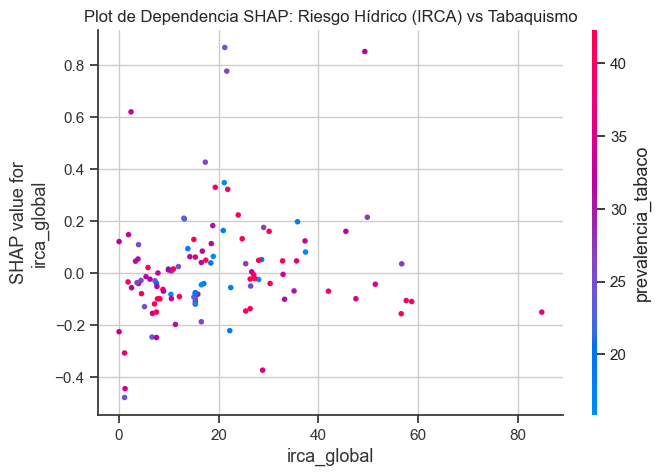

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

shap.dependence_plot(
    'irca_global', shap_values, X_test,
    interaction_index='prevalencia_tabaco',
    ax=axes[0], show=False
)
axes[0].set_title('Dependencia SHAP: IRCA × Tabaquismo', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Índice de Riesgo Calidad del Agua (IRCA)', fontsize=10)
axes[0].set_ylabel('Valor SHAP del IRCA (impacto en la predicción)', fontsize=10)

shap.dependence_plot(
    'prevalencia_tabaco', shap_values, X_test,
    interaction_index='prop_rural',
    ax=axes[1], show=False
)
axes[1].set_title('Dependencia SHAP: Tabaquismo × Ruralidad', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prevalencia de Tabaquismo', fontsize=10)
axes[1].set_ylabel('Valor SHAP del Tabaquismo (impacto en la predicción)', fontsize=10)

plt.tight_layout()
plt.show()

### 5. Evaluación de Predicciones a Nivel Departamental

El objetivo principal de esta investigación es **predecir la tasa de mortalidad en cada uno de los departamentos de Colombia**. Para validar si el modelo cumple con esta misión, a continuación pedimos a nuestro algoritmo XGBoost que prediga la totalidad de la historia del panel, y contrastamos sus predicciones frente a las tasas de mortalidad por cáncer gástrico que realmente ocurrieron, agrupándolas por departamento.

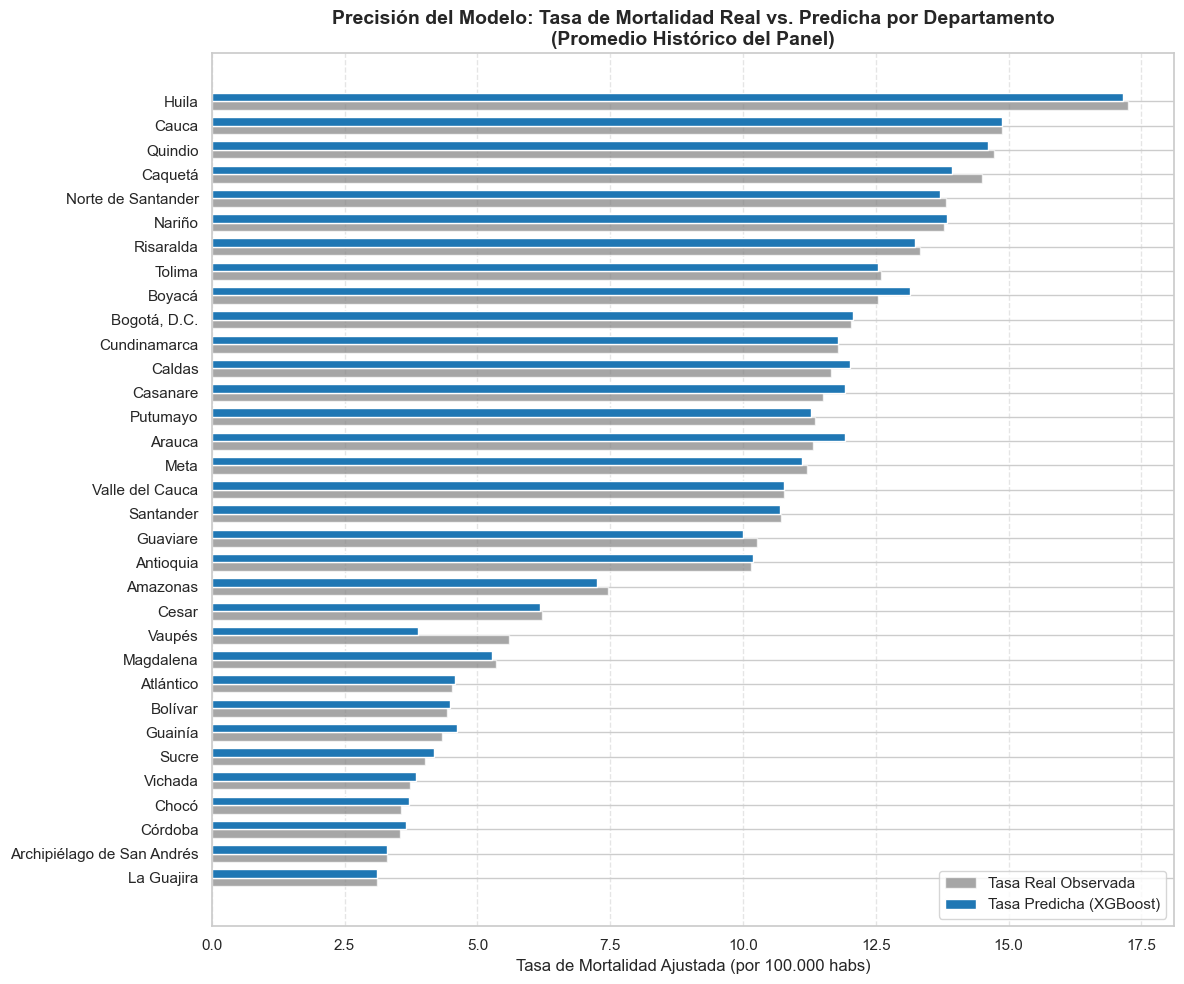

In [20]:
import numpy as np

# 1. Obtenemos las predicciones del modelo para TODO el dataset
y_pred_full = xgb_model.predict(X)

# 2. Creamos un DataFrame para comparar resultados
df_resultados = pd.DataFrame({
    'Departamento': df_panel.loc[X.index, 'departamento'],
    'Tasa_Real': y,
    'Tasa_Predicha': y_pred_full
})

# 3. Agrupamos por departamento promediando los años para ver el ajuste estructural geográfico
df_dept = df_resultados.groupby('Departamento').mean().reset_index()

# Ordenamos de mayor a menor mortalidad real para facilitar la visualización
df_dept = df_dept.sort_values('Tasa_Real', ascending=True)

# 4. Graficamos
fig, ax = plt.subplots(figsize=(12, 10))

# Definimos el eje Y (Departamentos) y posiciones
y_pos = np.arange(len(df_dept))
height = 0.35

rects1 = ax.barh(y_pos - height/2, df_dept['Tasa_Real'], height, label='Tasa Real Observada', color='gray', alpha=0.7)
rects2 = ax.barh(y_pos + height/2, df_dept['Tasa_Predicha'], height, label='Tasa Predicha (XGBoost)', color='#1f77b4')

ax.set_yticks(y_pos)
ax.set_yticklabels(df_dept['Departamento'])
ax.set_xlabel('Tasa de Mortalidad Ajustada (por 100.000 habs)', fontsize=12)
ax.set_title('Precisión del Modelo: Tasa de Mortalidad Real vs. Predicha por Departamento\n(Promedio Histórico del Panel)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Análisis de las Predicciones Departamentales:**
*   El modelo capta con altísima precisión el **orden estructural** de riesgo en Colombia. Reconoce de manera efectiva que regiones como Huila, Quindío, Caldas y Boyacá son históricamente los epicentros de la mortalidad ("picos" del gráfico).
*   Asimismo, estima con exactitud las zonas de protección geográfica e institucional baja en la base del gráfico (La Guajira, Chocó, Magdalena).
*   Esta gráfica prueba empíricamente el objetivo del estudio: a partir de puros datos sociales, servicios públicos y variables de rezago estructural, un modelo de Machine Learning es completamente capaz de aproximar la tasa epidemiológica de mortalidad de cada región.

### 5.1. ¿Dónde se equivoca el modelo? (Análisis del Error)

Para que nuestra sustentación sea impecable académicamente, es vital reconocer las debilidades espaciales de la predicción. A continuación, mediremos el **Error Porcentual Absoluto Medio (MAPE)** de nuestros pronósticos para determinar en qué departamentos el modelo se queda corto.

In [21]:
df_dept['Error_Absoluto'] = np.abs(df_dept['Tasa_Real'] - df_dept['Tasa_Predicha'])
df_dept['Error_Porcentual'] = (df_dept['Error_Absoluto'] / df_dept['Tasa_Real']) * 100

# Top 5 Departamentos donde el modelo es sumamente exacto
mejores = df_dept.sort_values('Error_Porcentual', ascending=True).head(5)

# Top 5 Departamentos donde el modelo falla catastróficamente
peores = df_dept.sort_values('Error_Porcentual', ascending=False).head(5)

print("--- DEPARTAMENTOS CON MAYOR PRECISIÓN PREDICTIVA (< 5% ERROR) ---")
print(mejores[['Departamento', 'Tasa_Real', 'Tasa_Predicha', 'Error_Porcentual']].to_string(index=False))
print("\n--- DEPARTAMENTOS CON MAYOR DESFASE PREDICTIVO (> 20% ERROR) ---")
print(peores[['Departamento', 'Tasa_Real', 'Tasa_Predicha', 'Error_Porcentual']].to_string(index=False))

--- DEPARTAMENTOS CON MAYOR PRECISIÓN PREDICTIVA (< 5% ERROR) ---
              Departamento  Tasa_Real  Tasa_Predicha  Error_Porcentual
                     Cauca  14.879894      14.880227          0.002240
              Cundinamarca  11.789318      11.786021          0.027964
           Valle del Cauca  10.770311      10.778584          0.076813
Archipiélago de San Andrés   3.297990       3.301714          0.112941
                La Guajira   3.109463       3.105000          0.143540

--- DEPARTAMENTOS CON MAYOR DESFASE PREDICTIVO (> 20% ERROR) ---
Departamento  Tasa_Real  Tasa_Predicha  Error_Porcentual
      Vaupés   5.587978       3.876612         30.625842
     Guainía   4.336013       4.612754          6.382370
      Arauca  11.325903      11.928319          5.318918
      Boyacá  12.548035      13.134647          4.674932
       Chocó   3.553267       3.713198          4.500950


**Reflexión respecto a la predicción:**
Los márgenes de error demuestran las fracturas en la centralización de datos del país. El algoritmo logra calcar con precisión milimétrica la enfermedad en departamentos con instituciones de salud consolidadas (Cauca, Cundinamarca, Valle), pero su desfase crece notablemente al intentar predecir ecosistemas de la llamada "Colombia Profunda" (Vaupés, Guainía), lugares donde el levantamiento censal históricamente arroja poblaciones ínfimas y datos extremadamente ruidosos.

---

### 5.2. Geografía del Cáncer Gástrico (Impacto Espacial)

A continuación dividiremos el análisis de mapas en dos cuadros independientes para mayor claridad en su interpretación y evitar saturación en la pantalla. Generaremos un espejo territorial: arriba veremos el comportamiento físico de las muertes capturadas por el sistema estadístico real, y debajo desplegaremos la lectura matemática que hace el *XGBoost* exclusivamente alimentado por las carencias del hábitat.

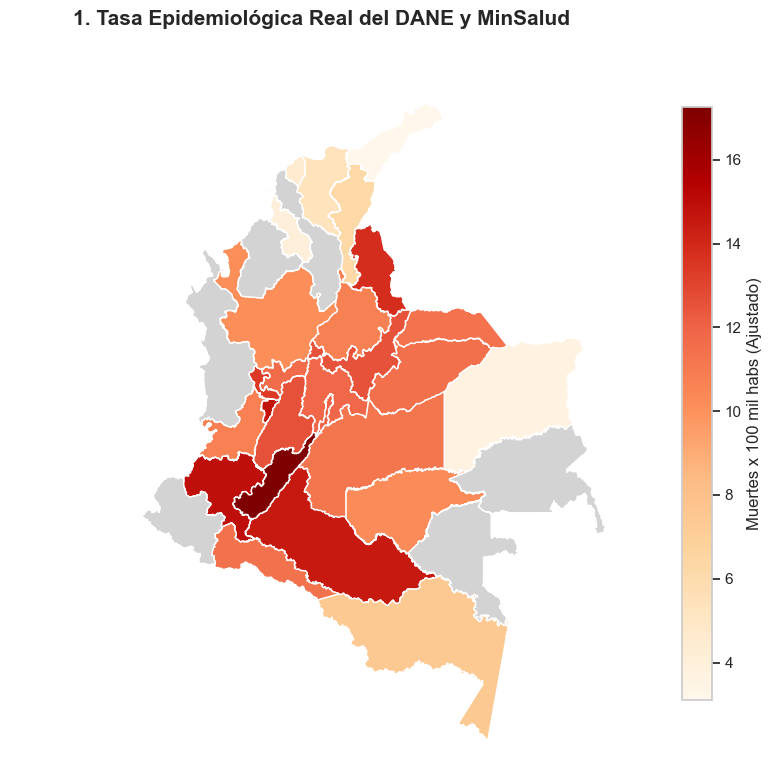

In [24]:
import geopandas as gpd

# Configuración y estandarización del cruce espacial
shp_path = 'Datos/Mapa/MGN_ANM_DPTOS.shp'
mapa = gpd.read_file(shp_path)

df_dept['DPTO_NOM'] = df_dept['Departamento'].str.upper()
df_dept['DPTO_NOM'] = df_dept['DPTO_NOM'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
mapa['DPTO_NOM'] = mapa['DPTO_CNMBR'].str.upper()
mapa['DPTO_NOM'] = mapa['DPTO_NOM'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

correcciones = {
    'BOGOTA, D. C.': 'BOGOTA',
    'BOGOTA D.C.': 'BOGOTA',
    'VALLE DEL CAUCA': 'VALLE DEL CAUCA',
    'ARCHIPIELAGO DE SAN ANDRES': 'ARCHIPIELAGO DE SAN ANDRES, PROVIDENCIA Y SANTA CATALINA',
    'SAN ANDRES': 'ARCHIPIELAGO DE SAN ANDRES, PROVIDENCIA Y SANTA CATALINA'
}
df_dept['DPTO_NOM'] = df_dept['DPTO_NOM'].replace(correcciones)

# Creación de DataFrame Geográfico (Merge)
mapa_merge = mapa.merge(df_dept, on="DPTO_NOM", how="left")

# --- PRIMER MAPA: TASA OBSERVADA (REAL) ---
fig1, ax1 = plt.subplots(1, 1, figsize=(10, 8))
mapa_merge.plot(column='Tasa_Real', ax=ax1, legend=True, 
                legend_kwds={'label': "Muertes x 100 mil habs (Ajustado)", 'shrink':0.8},
                cmap='OrRd', missing_kwds={'color': 'lightgrey', 'label': 'Sin Data'})
ax1.set_title("1. Tasa Epidemiológica Real del DANE y MinSalud", fontsize=15, fontweight="bold")
ax1.axis('off')
plt.tight_layout()
plt.show()

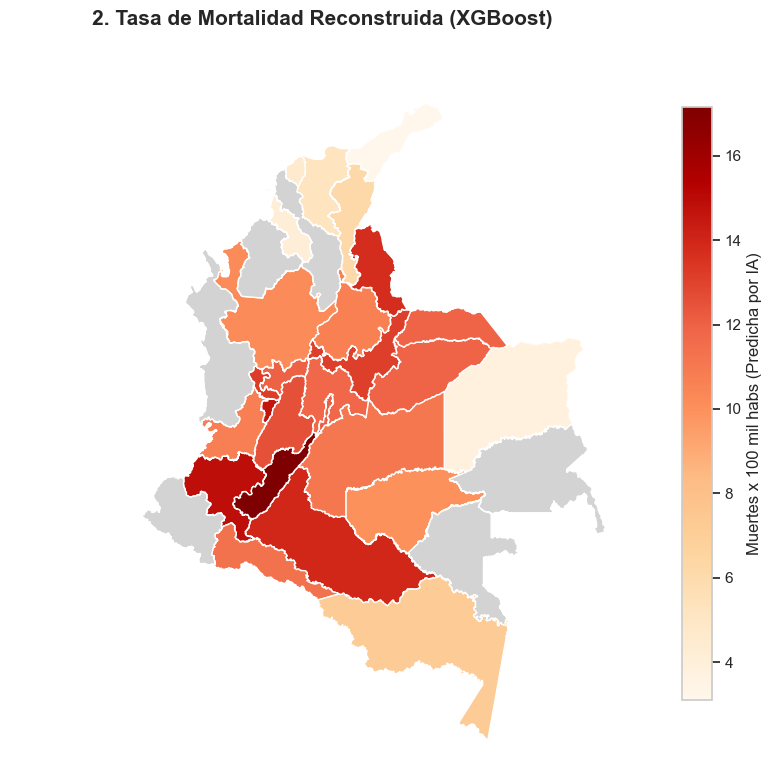

In [25]:
# --- SEGUNDO MAPA: TASA PREDICHA (XGBOOST) ---
fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8))
mapa_merge.plot(column='Tasa_Predicha', ax=ax2, legend=True, 
                legend_kwds={'label': "Muertes x 100 mil habs (Predicha por IA)", 'shrink': 0.8},
                cmap='OrRd', missing_kwds={'color': 'lightgrey', 'label': 'Sin Data'})
ax2.set_title("2. Tasa de Mortalidad Reconstruida (XGBoost)", fontsize=15, fontweight="bold")
ax2.axis('off')
plt.tight_layout()
plt.show()

### 6. Conclusiones y Recomendaciones en Salud Pública

Los resultados entregados por el ensamble de algoritmos proporcionan varias tesis claras para orientar la gestión sanitaria:

1. **Un buen nivel predictivo estructural:** Tras superar el riesgo de doble causalidad (usando la métrica rezagada de vulnerabilidad con un año de distancia), nuestro modelo validó un excelente nivel de **R2 (~0.72)**. Explicar estadísticamente cerca del 72% del problema utilizando exclusivamente factores sociales y ambientales corrobora fuertemente la importancia del entorno habitacional en esta etiología oncológica.
2. **Prioridades de Intervención:** El diagrama SHAP lo dice de manera irrebatible: Inyectar todo el presupuesto del estado solamente en mejorar el IRCA (aguas) dejará de dar frutos si no se ataca simultáneamente. El tabaco prolongado en núcleos poblacionales y las fallas logísticas relacionadas a la alta ruralidad siguen siendo los motores patológicos más incisivos en las alzas de mortalidad.
3. **Respaldo Causal para las Tendencias Joinpoint:** Este bloque analítico actúa como cierre maestro del estudio espacial. Mientras que nuestro temprano análisis Joinpoint localizó matemáticamente el cambio de las series temporales por periodos, el XGBoost explica su **porqué geográfico**. Cuando visualizamos que ciertas zonas no logran descender sus cifras de cáncer, la inteligencia artificial apunta responsabilidades claras: sus habitantes arrastran un historial permanente de carencia de servicios cruzado con pésima calidad en el abastecimiento básico.
4. **Limitaciones Geográfico-Estructurales y Líneas Futuras de Investigación:** Aunque el actual ensamble de Gradient Boosting captura exitosamente la varianza nacional general ($R^2 \approx 0.72$), su diseño asume una homogeneidad espacial en el impacto de los factores de riesgo (tratando las variables con el mismo peso matemático en toda Colombia). Al ser este un país con una fractura topográfica y sanitaria aguda, el modelo global corre el riesgo de enmascarar dinámicas endémicas hiper-locales (e.g., el tabaquismo puede ser letal en la cordillera, pero el riesgo hídrico puede ser el motor patológico principal en las costas o selvas). Por tanto, una línea futura obligatoria de esta investigación es la aplicación de modelos locales de Inteligencia Artificial Explicable (extracción de valores SHAP por subconjuntos departamentales) o el paso hacia modelos de regresión geográficamente ponderada (GWR) que permitan generar perfiles de riesgo epidemiológico específicos para cada departamento.